# AI Impacted Student Performance Supervised Machine Learning Predictive Model

## Problem Statement:The objective of this project is to develop a Machine Learning regression model that can predict a student's Skill_Retention_Score primarily based on their Generative AI usage behavior. Since most of the features in the dataset are related to AI usage, such as weekly Generative AI hours, primary use case, prompt engineering skill, tool diversity, paid subscription status, and perceived AI dependency, the model aims to analyze how these AI-related factors influence a student's ability to retain learned skills over time. By leveraging these features along with relevant academic and well-being indicators, the model seeks to estimate skill retention and provide insights into the impact of Generative AI on long-term learning outcomes.

In [147]:
import pandas as pd
import numpy as np
AI_Impacted_Student_Performance=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Regression projects/AI_Impacted_Student_performance/ai_student_impact_dataset.csv")
print(AI_Impacted_Student_Performance.shape)
AI_Impacted_Student_Performance.drop_duplicates()
print(AI_Impacted_Student_Performance.shape)

(50000, 16)
(50000, 16)


In [148]:
import datetime

In [149]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [150]:
AI_Impacted_Student_Performance.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


## Target Variable is Skill_Retention_Score

<Axes: >

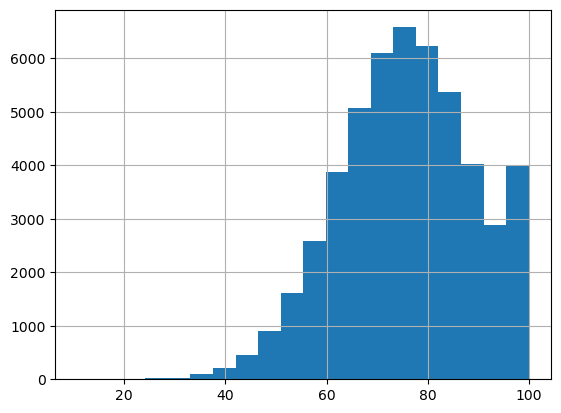

In [151]:
AI_Impacted_Student_Performance['Skill_Retention_Score'].hist(bins=20)

In [152]:
AI_Impacted_Student_Performance.drop('Student_ID',axis=1,inplace=True)

In [153]:
AI_Impacted_Student_Performance.head(10)

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [154]:
AI_Impacted_Student_Performance.shape

(50000, 15)

## Exploratory Data Analysis

In [155]:
AI_Impacted_Student_Performance.nunique()

Major_Category                   5
Year_of_Study                    5
Pre_Semester_GPA              2389
Weekly_GenAI_Hours            3566
Primary_Use_Case                 5
Prompt_Engineering_Skill         3
Tool_Diversity                   5
Paid_Subscription                2
Traditional_Study_Hours       2516
Perceived_AI_Dependency         10
Institutional_Policy             3
Anxiety_Level_During_Exams      10
Post_Semester_GPA             2269
Skill_Retention_Score         5872
Burnout_Risk_Level               3
dtype: int64

In [156]:
AI_Impacted_Student_Performance.columns

Index(['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

CategoricalColumns:['Major_Category', 'Year_of_Study','Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription','Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams','Burnout_Risk_Level']
ContinousColumns:['Pre_Semester_GPA',
       'Weekly_GenAI_Hours','Traditional_Study_Hours','Post_Semester_GPA',
       'Skill_Retention_Score']

In [157]:
AI_Impacted_Student_Performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Prompt_Engineering_Skill    50000 non-null  object 
 6   Tool_Diversity              50000 non-null  int64  
 7   Paid_Subscription           50000 non-null  bool   
 8   Traditional_Study_Hours     50000 non-null  float64
 9   Perceived_AI_Dependency     50000 non-null  int64  
 10  Institutional_Policy        50000 non-null  object 
 11  Anxiety_Level_During_Exams  50000 non-null  int64  
 12  Post_Semester_GPA           50000 non-null  float64
 13  Skill_Retention_Score       500

In [158]:
AI_Impacted_Student_Performance.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


## Uni Variate Analysis by Histogram

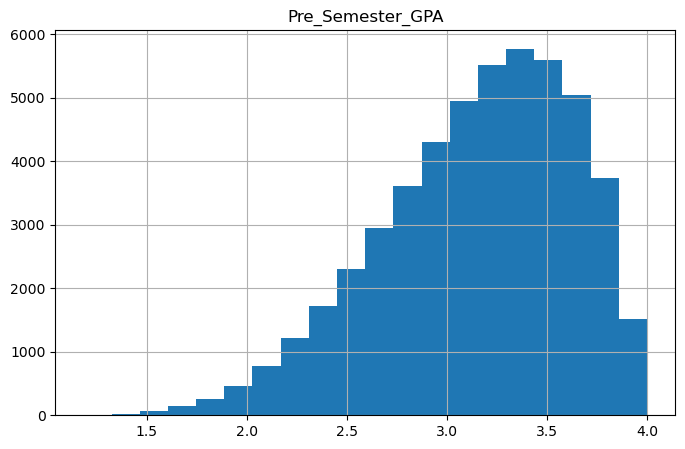

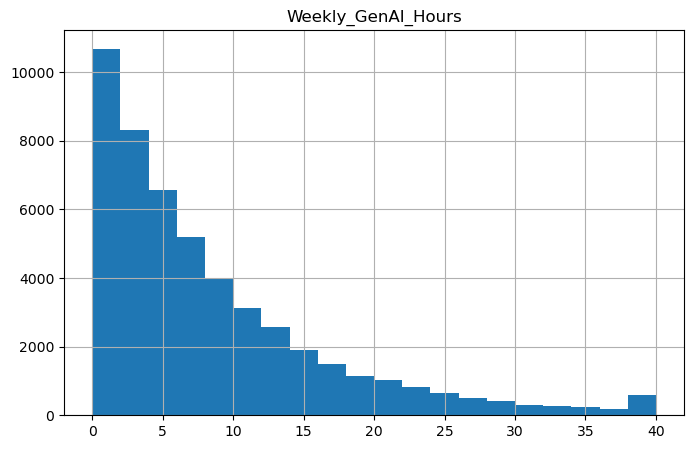

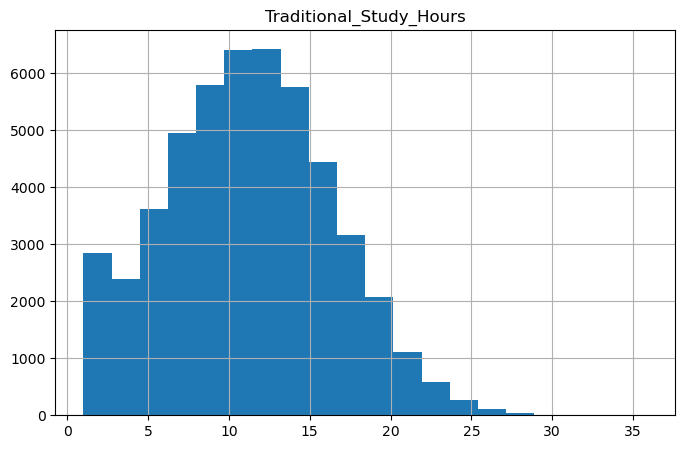

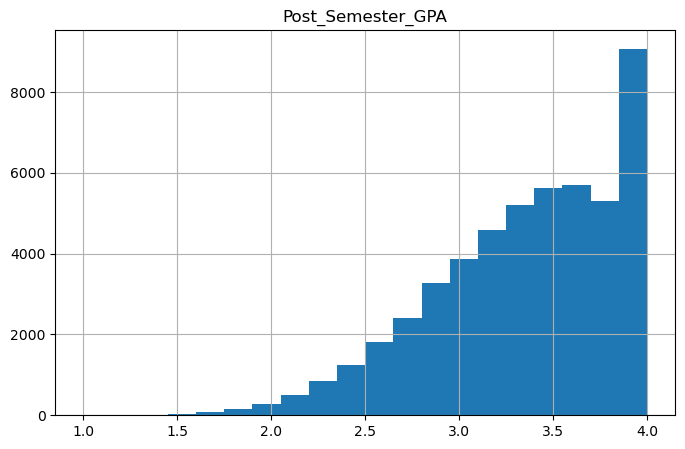

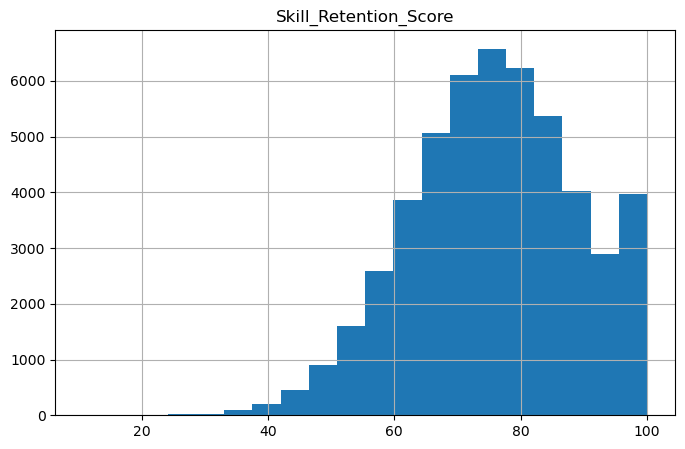

In [159]:
ContinousColumns=['Pre_Semester_GPA', 'Weekly_GenAI_Hours','Traditional_Study_Hours','Post_Semester_GPA', 'Skill_Retention_Score']
for cols in ContinousColumns:
    AI_Impacted_Student_Performance.hist(cols,bins=20, figsize=(8,5))

### No Need for outlier treatment

## Uni Variate Analysis by Bar Charts

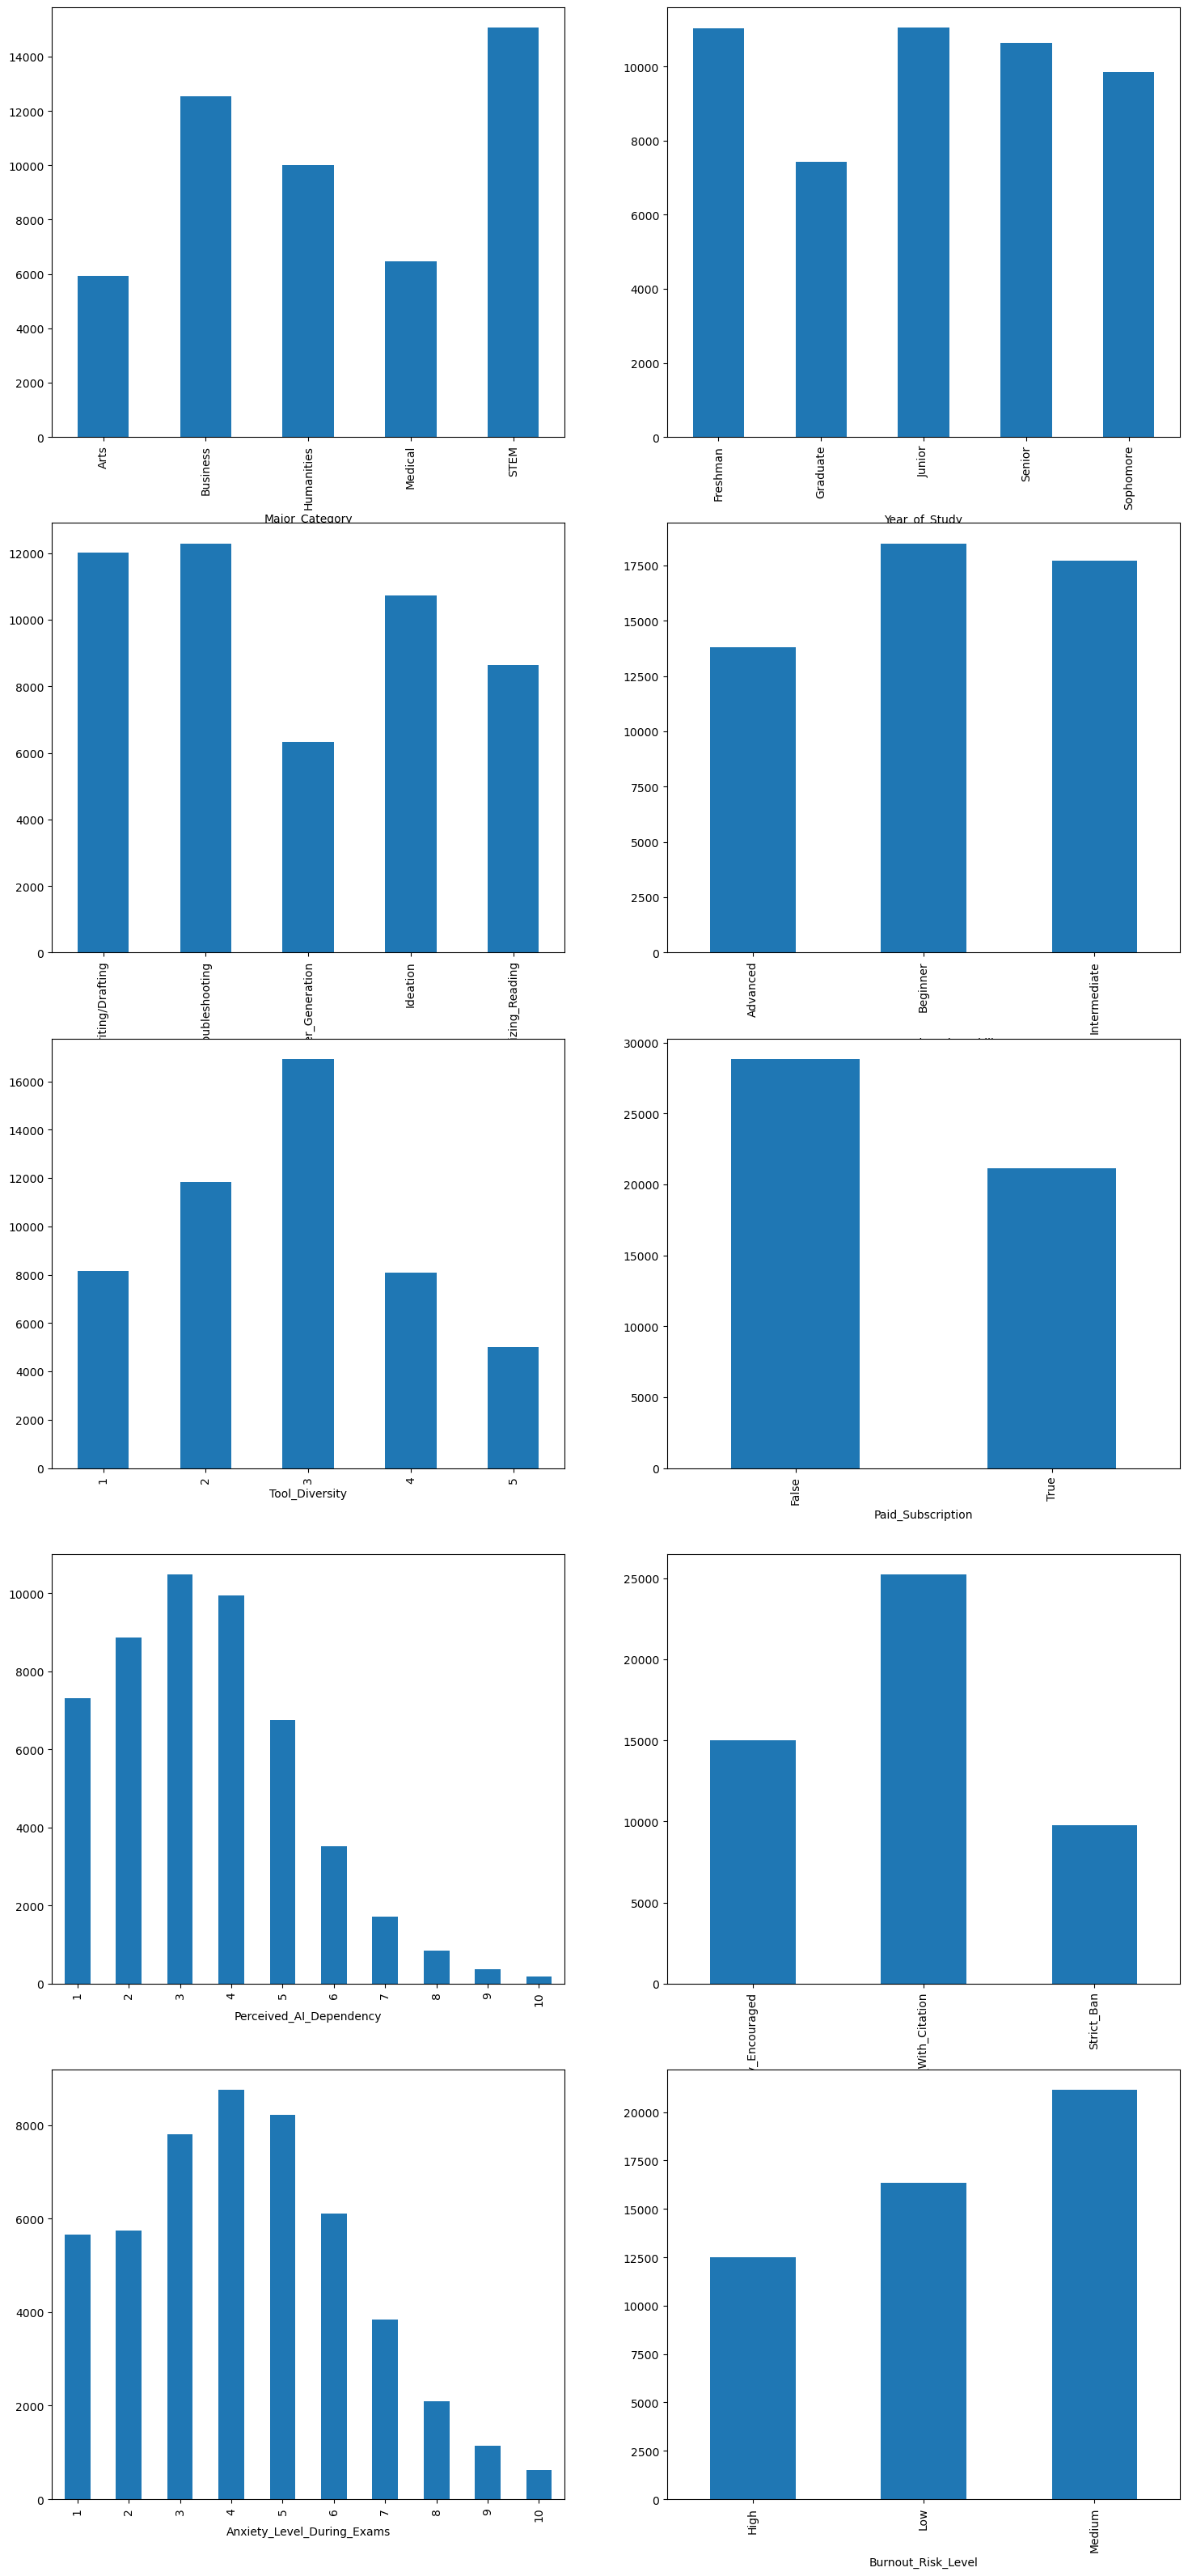

In [160]:
CategoricalColumns=['Major_Category', 'Year_of_Study','Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription','Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams','Burnout_Risk_Level']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(5,2,figsize=(18,40))
subplots=subplots.flatten()
for cols ,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    AI_Impacted_Student_Performance.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])


### No need for Imbalance treatment

### Missing value treatment is not needed.

In [161]:
AI_Impacted_Student_Performance.isnull().sum()

Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

## Continuous Vs Continuous -- Scatter Charts

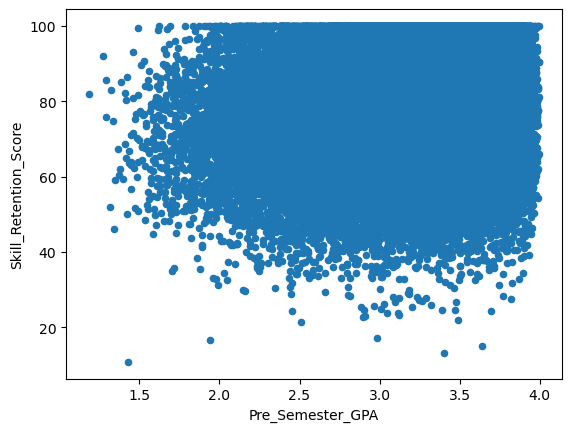

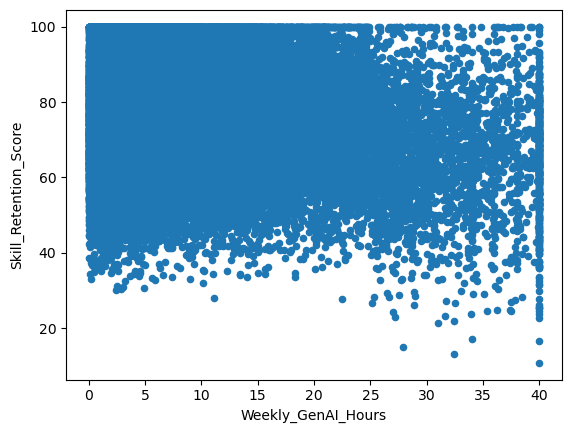

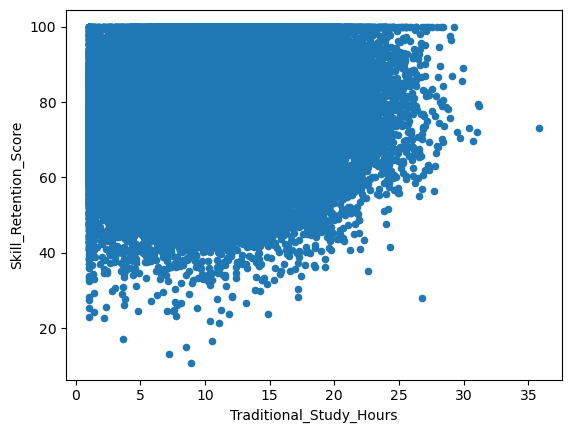

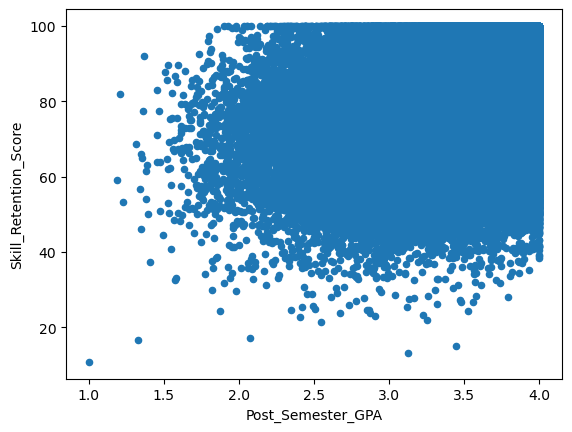

In [162]:
ContinousColumns=['Pre_Semester_GPA', 'Weekly_GenAI_Hours','Traditional_Study_Hours','Post_Semester_GPA']
for cols in ContinousColumns:
    AI_Impacted_Student_Performance.plot.scatter(x=cols,y='Skill_Retention_Score')

## On the basis of visual correlation analysis, The predictors have a low correlation with the target variable.

## Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [163]:
ContinousColumns=['Pre_Semester_GPA', 'Weekly_GenAI_Hours','Traditional_Study_Hours','Post_Semester_GPA','Skill_Retention_Score']
corr_data=AI_Impacted_Student_Performance[ContinousColumns].corr()
corr_data

,Pre_Semester_GPA,Weekly_GenAI_Hours,Traditional_Study_Hours,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000000,-0.001084,-0.004620,0.926781,0.099019
Weekly_GenAI_Hours,-0.001084,1.000000,-0.157368,-0.018600,-0.118099
Traditional_Study_Hours,-0.004620,-0.157368,1.000000,0.137653,0.147565
Post_Semester_GPA,0.926781,-0.018600,0.137653,1.000000,0.169616
Skill_Retention_Score,0.099019,-0.118099,0.147565,0.169616,1.000000


### On the basis of  Statistical analysis, The predictors have a low correlation with the target variable.

## Categorical Vs Continuous -- Box Plots

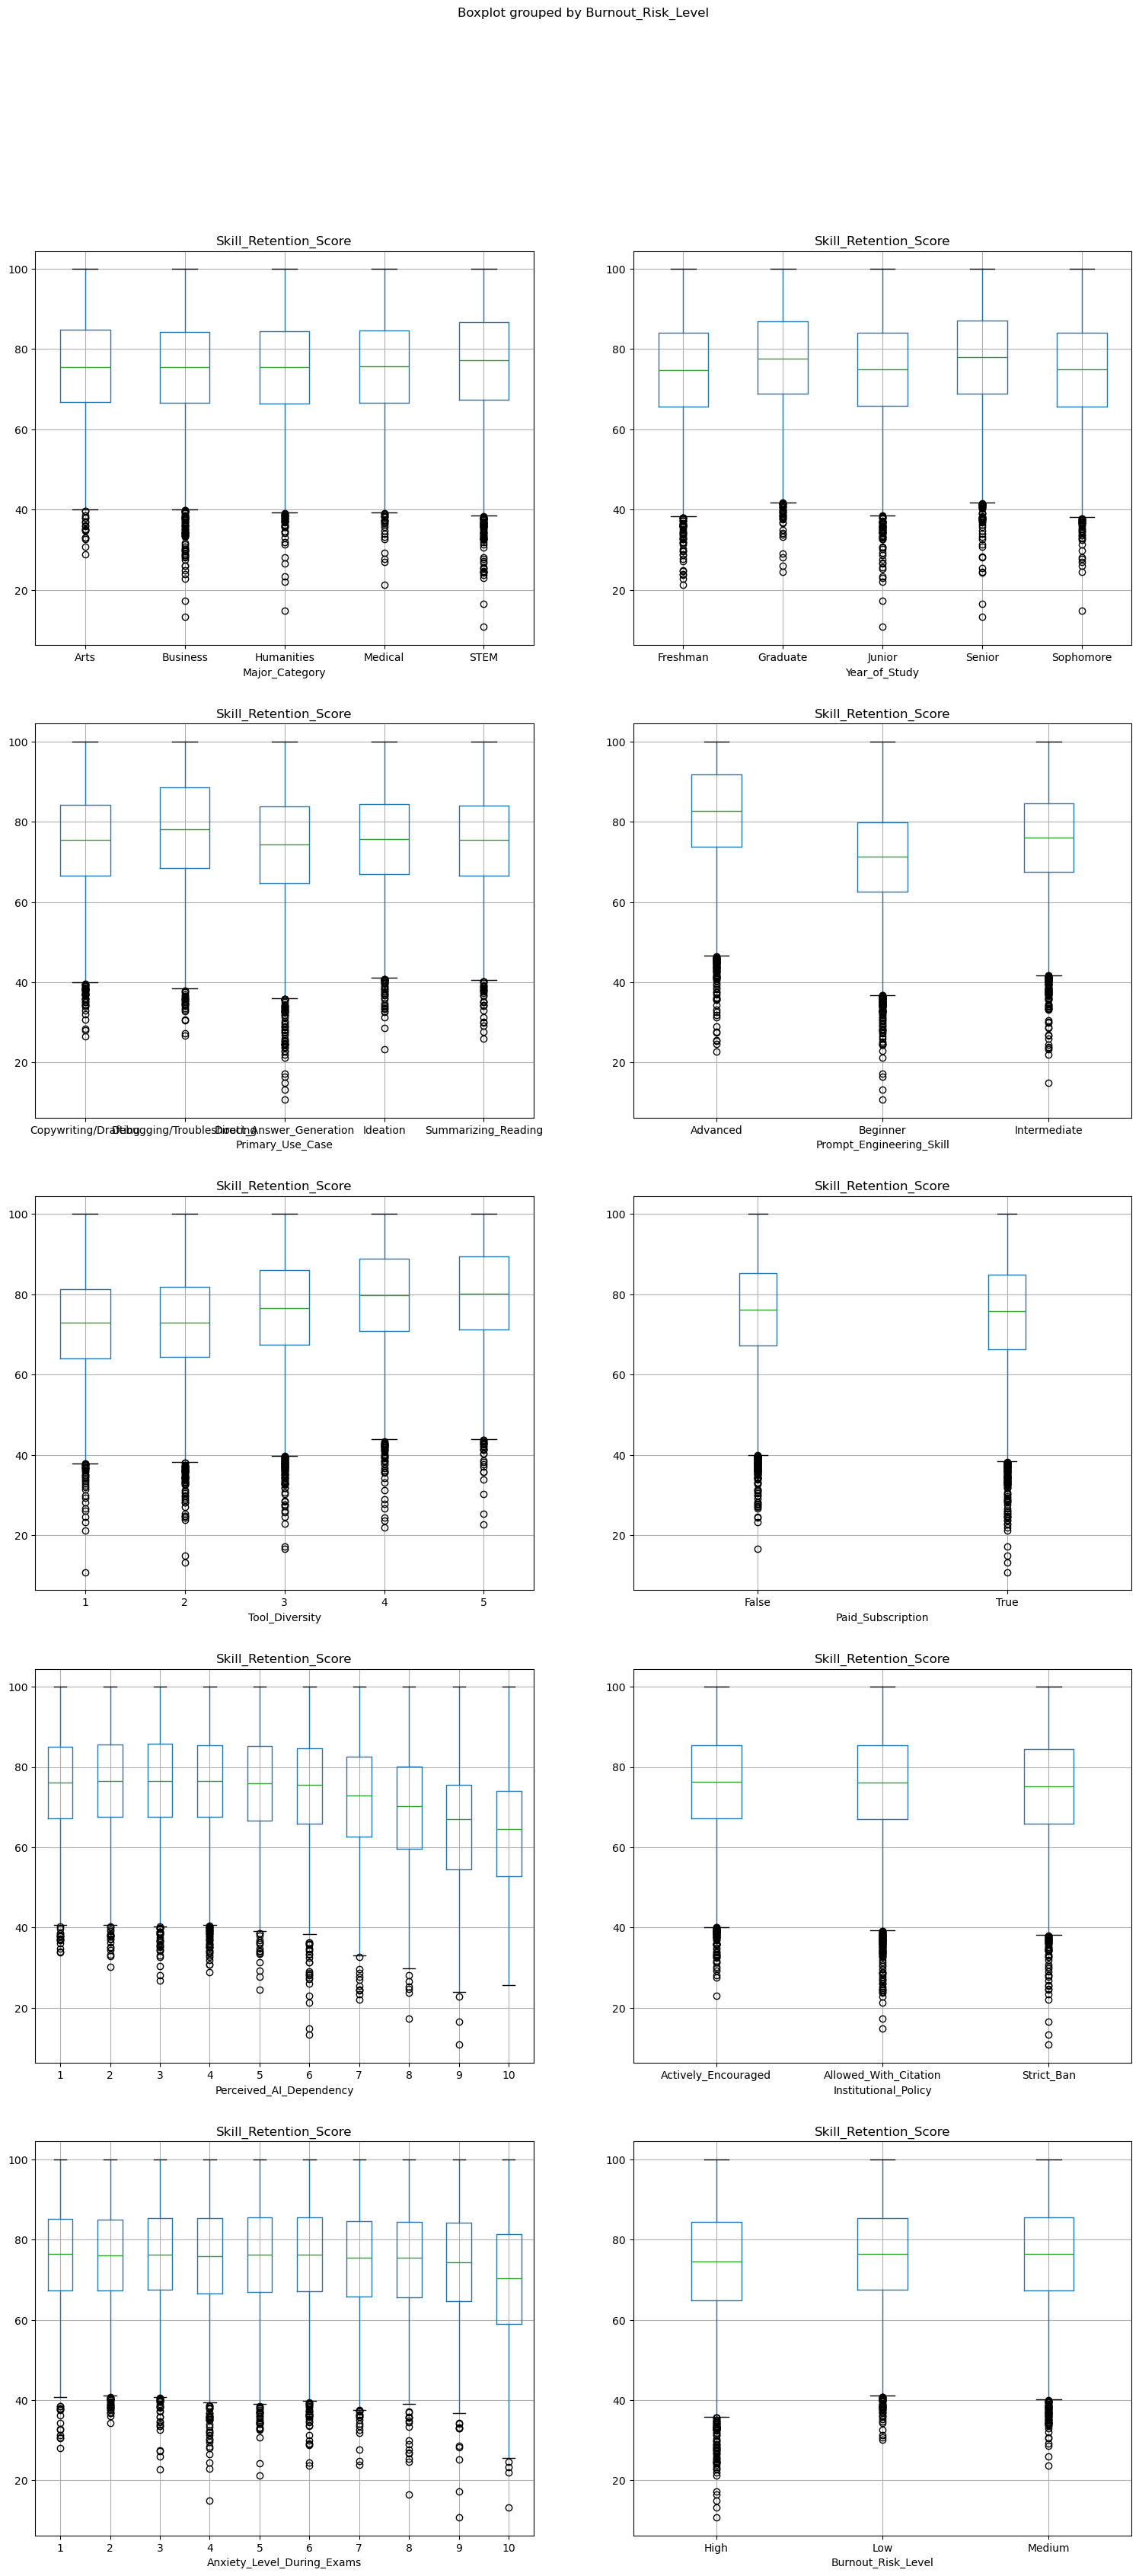

In [164]:
CategoricalColumns=['Major_Category', 'Year_of_Study','Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription','Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams','Burnout_Risk_Level']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(5,2,figsize=(18,40))
subplots=subplots.flatten()
for cols ,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    AI_Impacted_Student_Performance.boxplot(column='Skill_Retention_Score',by=cols,vert=True,ax=subplots[no_of_cols])


## On the basis of visual correlation analysis, The predictors have a high correlation with the target variable.

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [165]:
CategoricalColumns=['Major_Category', 'Year_of_Study','Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription','Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams','Burnout_Risk_Level']
def functionAnova(inpData,CategoricalColumns,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in CategoricalColumns:
        CategoricalGroupLists=inpData.groupby(cols)[targetVariable].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.5:
            print(cols,' is correlated with Skill_Retention_Score and p value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with Skill_Retention_Score and p value is:',AnovaResults[1])
    return SelectedPredictors   
functionAnova(inpData=AI_Impacted_Student_Performance,CategoricalColumns=['Major_Category', 'Year_of_Study','Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription','Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams','Burnout_Risk_Level'],
            targetVariable= 'Skill_Retention_Score')


Major_Category  is correlated with Skill_Retention_Score and p value is: 1.1941521630294223e-26
Year_of_Study  is correlated with Skill_Retention_Score and p value is: 2.7560778344764012e-120
Primary_Use_Case  is correlated with Skill_Retention_Score and p value is: 5.321958605562384e-120
Prompt_Engineering_Skill  is correlated with Skill_Retention_Score and p value is: 0.0
Tool_Diversity  is correlated with Skill_Retention_Score and p value is: 0.0
Paid_Subscription  is correlated with Skill_Retention_Score and p value is: 7.21102385471154e-08
Perceived_AI_Dependency  is correlated with Skill_Retention_Score and p value is: 3.1911687911053e-163
Institutional_Policy  is correlated with Skill_Retention_Score and p value is: 5.815291717559416e-11
Anxiety_Level_During_Exams  is correlated with Skill_Retention_Score and p value is: 5.984343818933094e-38
Burnout_Risk_Level  is correlated with Skill_Retention_Score and p value is: 5.037813399157593e-50


['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Burnout_Risk_Level']

## On the basis of Statistical correlation analysis, The predictors have a high correlation with the target variable.

In [166]:
AI_Impacted_Student_Performance.columns

Index(['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [167]:
AI_Impacted_Student_Performance.columns

Index(['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='object')

In [168]:
selectedColumns=['Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Burnout_Risk_Level']
DataForML_AI_Impacted_Student_Performance=AI_Impacted_Student_Performance[selectedColumns]
DataForML_AI_Impacted_Student_Performance.to_pickle('DataForML_AI_Impacted_Student_Performance.pkl')
DataForML_AI_Impacted_Student_Performance=pd.read_pickle('DataForML_AI_Impacted_Student_Performance.pkl')
DataForML_AI_Impacted_Student_Performance.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,Medium


In [169]:
DataForML_AI_Impacted_Student_Performance=pd.get_dummies(DataForML_AI_Impacted_Student_Performance)

## Converting the binary nominal variable to numeric using 1/0 mapping

In [170]:
DataForML_AI_Impacted_Student_Performance.replace({True:1,False:0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_196708\2688800584.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForML_AI_Impacted_Student_Performance.replace({True:1,False:0},inplace=True)


In [171]:
DataForML_AI_Impacted_Student_Performance.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
0,2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0
1,3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0
2,3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1
3,3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1
4,3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1


In [172]:
DataForML_AI_Impacted_Student_Performance['Skill_Retention_Score']=AI_Impacted_Student_Performance['Skill_Retention_Score']
DataForML_AI_Impacted_Student_Performance.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Skill_Retention_Score
0,2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,86.44
1,3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,69.39
2,3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,73.93
3,3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,63.58
4,3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,100.00


## Splitting the data into Training and Testing sample

In [173]:
DataForML_AI_Impacted_Student_Performance.columns

Index(['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
       'Post_Semester_GPA', 'Major_Category_Arts', 'Major_Category_Business',
       'Major_Category_Humanities', 'Major_Category_Medical',
       'Major_Category_STEM', 'Year_of_Study_Freshman',
       'Year_of_Study_Graduate', 'Year_of_Study_Junior',
       'Year_of_Study_Senior', 'Year_of_Study_Sophomore',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Prompt_Engineering_Skill_Advanced',
       'Prompt_Engineering_Skill_Beginner',
       'Prompt_Engineering_Skill_Intermediate',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Stric

In [174]:
DataForML_AI_Impacted_Student_Performance.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Skill_Retention_Score
0,2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,86.44
1,3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,69.39
2,3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,73.93
3,3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,63.58
4,3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,100.00


In [180]:
predictors=['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
       'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
       'Post_Semester_GPA', 'Major_Category_Arts', 'Major_Category_Business',
       'Major_Category_Humanities', 'Major_Category_Medical',
       'Major_Category_STEM', 'Year_of_Study_Freshman',
       'Year_of_Study_Graduate', 'Year_of_Study_Junior',
       'Year_of_Study_Senior', 'Year_of_Study_Sophomore',
       'Primary_Use_Case_Copywriting/Drafting',
       'Primary_Use_Case_Debugging/Troubleshooting',
       'Primary_Use_Case_Direct_Answer_Generation',
       'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading',
       'Prompt_Engineering_Skill_Advanced',
       'Prompt_Engineering_Skill_Beginner',
       'Prompt_Engineering_Skill_Intermediate',
       'Institutional_Policy_Actively_Encouraged',
       'Institutional_Policy_Allowed_With_Citation',
       'Institutional_Policy_Strict_Ban', 'Burnout_Risk_Level_High',
       'Burnout_Risk_Level_Low', 'Burnout_Risk_Level_Medium']

targetVariable='Skill_Retention_Score'
X=DataForML_AI_Impacted_Student_Performance[predictors].values
y=DataForML_AI_Impacted_Student_Performance[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(40000, 32)
(40000,)
(10000, 32)
(10000,)


In [181]:
DataForML_AI_Impacted_Student_Performance.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Skill_Retention_Score
0,2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,86.44
1,3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,69.39
2,3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,73.93
3,3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,63.58
4,3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,100.00


## Linear Regression

In [177]:
from sklearn.linear_model import LinearRegression
RegModel=LinearRegression()
LREG=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,LREG.predict(X_train))*100),2),'%')
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(LREG,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


R2 Value: 17.99 %
86.28851009028114
89.1309820218571
[85.98119378 86.20836784 86.26291403 86.15560551 86.15167197]
Final Accuracy of the Model: 86.15 %


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
RegModel=DecisionTreeRegressor(max_depth=8,criterion='squared_error')
DT=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,DT.predict(X_train))*100),2),'%')
Feature_Importances=pd.Series(DT.feature_importances_,index=predictors)
Feature_Importances.nlargest(10).plot(kind='barh')
prediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=MAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean(abs(orig-pred)/orig)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(DT,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


## Random Forest Regressor

RandomForestRegressor()
R2 Value: 0.8799995809007884
mse 150.54756127271497
Accuracy 86.04211698450825
0:01:28.016697


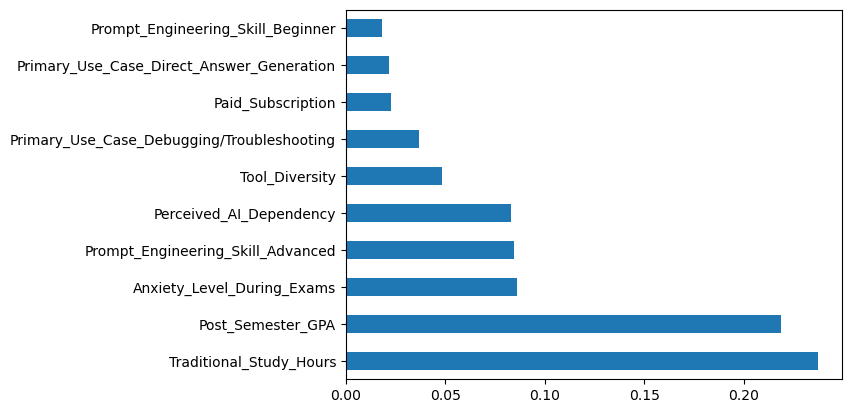

In [131]:
from datetime import datetime
start_time=datetime.now()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
RegModel = RandomForestRegressor(n_estimators=100,criterion='squared_error')
 
#Printing all the parameters of Random Forest
print(RegModel)
 
#Creating the model on Training Data
RF=RegModel.fit(X_train,y_train)
prediction=RF.predict(X_test) 
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, RF.predict(X_train)))
mse = mean_squared_error(y_test, prediction)
print('mse',mse)
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

end_time=datetime.now()
et=end_time-start_time
print(et)

## XGBRegressor

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0999, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)
R2 Value: 0.9420253989350694
Final Accuracy of the Model: 86.0 %


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Skill_Retention_Score,PredictedSkill_Retention_Score
0,2.768,1.17,4.0,0.0,11.53,3.0,1.0,3.195,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,99.12,89.764626
1,3.357,5.03,2.0,1.0,20.26,1.0,1.0,3.571,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,96.81,78.963699
2,3.388,8.53,2.0,1.0,9.54,2.0,3.0,3.572,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,77.63,72.908226
3,3.702,5.09,1.0,0.0,11.29,2.0,4.0,3.972,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,96.58,75.419731
4,3.142,2.88,3.0,0.0,7.58,1.0,2.0,3.288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,79.73,79.045570


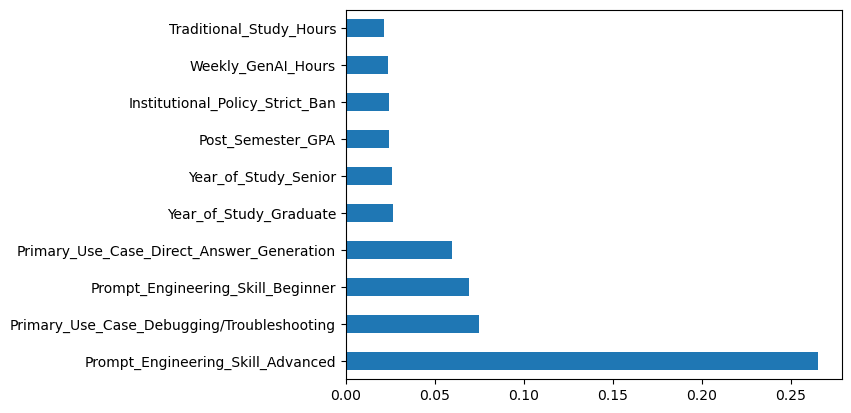

In [178]:
from xgboost import XGBRegressor
RegModel=XGBRegressor(max_depth=9, learning_rate=0.0999, n_estimators=600, objective='reg:squarederror', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(RegModel)
 
#Creating the model on Training Data
XGB=RegModel.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics  
print('R2 Value:',metrics.r2_score(y_train, XGB.predict(X_train)))
 
#Measuring accuracy on Testing Data
#print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction

print('Final Accuracy of the Model:',round(100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100),0),'%')
TestingDataResults.head()

## AdaBoost Regressor

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),
                  learning_rate=0.001, n_estimators=400)
R2 Value: 0.08449182590126703
Accuracy 85.46238602473571


,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Skill_Retention_Score,PredictedSkill_Retention_Score
0,2.768,1.17,4.0,0.0,11.53,3.0,1.0,3.195,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,99.12,81.933456
1,3.357,5.03,2.0,1.0,20.26,1.0,1.0,3.571,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,96.81,73.353180
2,3.388,8.53,2.0,1.0,9.54,2.0,3.0,3.572,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,77.63,73.353180
3,3.702,5.09,1.0,0.0,11.29,2.0,4.0,3.972,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,96.58,73.353180
4,3.142,2.88,3.0,0.0,7.58,1.0,2.0,3.288,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,79.73,81.933456


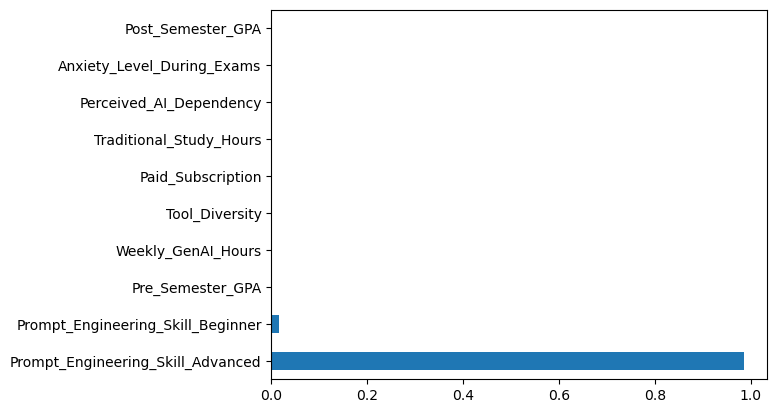

In [103]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
 
#Choosing Decision Tree with 1 level as the weak learner
DTR=DecisionTreeRegressor(max_depth=1)
RegModel = AdaBoostRegressor(n_estimators=400, estimator=DTR,learning_rate=0.001)
 
#Printing all the parameters of Adaboost
print(RegModel)
 
#Creating the model on Training Data
AB=RegModel.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, AB.predict(X_train)))

#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
#Printing some sample values of prediction 
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors) 
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head() 

## XGBoost is selected for deploying and Model Deployment on Production Data

In [197]:
NewData=pd.DataFrame(data=[
[2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0],
[3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0],
[3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1],
[3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1],
[3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1],
[3.102,12.44,3,1,11.25,4,5,3.281,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0],
[2.987,18.55,2,0,9.14,6,7,3.115,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0],
[3.456,4.28,5,1,18.22,2,3,3.688,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0],
[2.765,27.13,1,0,7.33,8,8,2.812,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0],
[3.901,2.74,4,1,20.15,1,2,4.000,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0],
[3.212,15.60,3,0,10.41,5,6,3.354,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1],
[2.884,30.22,2,1,6.88,9,9,2.945,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0],
[3.667,5.14,5,0,17.92,2,4,3.810,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0],
[3.145,11.87,3,0,12.35,4,5,3.276,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1],
[2.556,22.91,1,1,8.74,7,8,2.601,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,1,0,0],
[3.744,3.45,4,0,18.10,2,3,3.901,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0],
[3.331,14.20,2,0,11.02,5,6,3.492,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1],
[2.975,25.60,1,1,7.15,8,7,3.041,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0],
[3.588,6.73,5,0,16.84,3,4,3.702,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0],
[3.120,19.11,2,0,9.78,6,8,3.184,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0],
[3.854,1.98,5,1,21.45,1,2,4.000,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0],
[2.690,28.35,1,0,5.92,9,9,2.744,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0],
[3.470,8.42,4,0,14.56,3,5,3.628,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1],
[3.011,17.88,2,1,10.24,6,7,3.108,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0],
[3.699,4.11,5,0,19.05,2,3,3.851,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0],
[2.843,24.90,1,1,7.88,8,8,2.936,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0],
[3.276,10.33,3,0,13.27,4,5,3.412,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,1],
[3.918,2.55,5,1,22.30,1,1,4.000,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0],
[3.055,16.47,2,0,10.86,5,6,3.189,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1],
[2.777,26.18,1,1,6.43,9,9,2.851,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,1,0,0]
],columns=predictors)

In [198]:
newX=NewData.values

In [199]:
pred=XGB.predict(newX)

In [200]:
def GeneratePred(inpData):
    newX=inpData.values
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return (inpData)

In [201]:
ProductionDataPredicted=GeneratePred(inpData=NewData)

In [202]:
ProductionDataPredicted.head()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Major_Category_Arts,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Year_of_Study_Freshman,Year_of_Study_Graduate,Year_of_Study_Junior,Year_of_Study_Senior,Year_of_Study_Sophomore,Primary_Use_Case_Copywriting/Drafting,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Advanced,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Actively_Encouraged,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_High,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium,Prediction
0,2.418,23.31,1,1,8.13,5,6,2.393,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,84.561897
1,3.821,1.12,5,0,16.65,3,9,3.696,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,69.524719
2,3.398,21.26,2,0,10.35,5,9,3.499,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,63.278496
3,3.789,1.82,4,0,15.23,2,2,4.000,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,67.198555
4,3.635,9.29,4,0,12.55,4,4,3.798,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,91.776100


### refer:https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval